<a href="https://colab.research.google.com/github/leweieeeee/Transformer-Warm-Start-ADAPT-VQE/blob/main/V6_1_ADAPT_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pandas
%pip install numpy
%pip install torch
%pip install matplotlib

In [ ]:
%pip install pipreqs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.4 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=1625c288c0cce64d93bd226bd16c7e1fe211f3480a7db706fa61e3fdab2d4dca
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.12.3 which is incompatible.


In [ ]:
!python --version
!pipreqs . --force

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import glob

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import math

In [ ]:
files = [
    "H2_combined_dataset.csv",
    "LiH_combined_dataset.csv",
    "BeH2_combined_dataset.csv",
    "H4_combined_dataset.csv",
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df = df.drop(columns=["energy", "time"])
    df["molecule"] = f.replace("_combined_dataset.csv", "")
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

combined = combined.rename(columns={"molecule": "molecule_id"})

all_steps = combined[["molecule_id", "step"]].drop_duplicates()

train_steps = all_steps.sample(frac=0.8, random_state=42)
val_steps   = all_steps.drop(train_steps.index)

train_df = combined.merge(train_steps, on=["molecule_id", "step"])
val_df   = combined.merge(val_steps,   on=["molecule_id", "step"])


In [ ]:
class CircuitDataset(Dataset):
    def __init__(self, df, energy_col="E"):
        self.df = df.copy()
        # numeric params, missing → -1
        self.df["param"] = pd.to_numeric(self.df["param"], errors="coerce").fillna(-1.0)
        theta_vals = self.df["param"].astype(float).values
        has = theta_vals != -1
        # sin/cos features
        self.df["param_sin"] = np.where(has, np.sin(theta_vals), 0.0)
        self.df["param_cos"] = np.where(has, np.cos(theta_vals), 0.0)

        # map gate_type → ID
        gates = self.df["gate_type"].unique().tolist()
        self.gate2id = {"PauliX": 1,"SingleExcitation": 2, "DoubleExcitation": 3,
}
        self.df["gate_id"] = self.df["gate_type"].map(self.gate2id).fillna(0).astype(int)

        natural_max = int(self.df.groupby("step").size().max())
        self.max_len = natural_max
        print(natural_max)
        self.steps = sorted(self.df["step"].unique().tolist())

        gate_seqs, param_seqs, next_gate_ids, targets = [], [], [], []
        self.lengths = []

        for s in self.steps:
            sub = self.df[self.df["step"] == s].sort_values("depth")
            g   = sub["gate_id"].to_numpy(dtype=int)
            p   = sub[["param_sin","param_cos"]].to_numpy(dtype=float)
            raw = sub["param"].to_numpy(dtype=float)
            L   = len(g)

            if raw[-1] == -1:
                continue

            next_sub = self.df[self.df["step"] == s+1].sort_values("depth")
            if next_sub.empty or len(next_sub) <= L or next_sub["param"].iloc[L] == -1:
                continue

            theta_next = next_sub["param"].iloc[L]
            gate_next  = next_sub["gate_id"].iloc[L]

            targets.append([math.sin(theta_next), math.cos(theta_next)])
            next_gate_ids.append(int(gate_next))

            pad = self.max_len - L
            gate_seqs.append(np.concatenate([g, np.zeros(pad, dtype=int)]))
            param_seqs.append(np.concatenate([p, np.zeros((pad,2), dtype=float)]))
            self.lengths.append(L)

        self.gate_seqs     = np.stack(gate_seqs)
        self.param_seqs    = np.stack(param_seqs)
        self.next_gate_ids = np.array(next_gate_ids, dtype=int)
        self.targets       = np.array(targets, dtype=float)
        #self.steps         = list(range(len(self.targets)))

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            "gate_ids":     torch.tensor(self.gate_seqs[idx],     dtype=torch.long),
            "params":       torch.tensor(self.param_seqs[idx],     dtype=torch.float32),
            "next_gate_id": torch.tensor(self.next_gate_ids[idx],  dtype=torch.long),
            "target":       torch.tensor(self.targets[idx],        dtype=torch.float32),
        }

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * -(np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


In [ ]:
class TransformerRegressor(nn.Module):
    def __init__(self,
                 num_gates,
                 d_model=64,       #from 128
                 nhead=8,
                 num_layers=2,     #from 4
                 dropout=0.1,      #decrease dropout
                 max_len=50):
        super().__init__()
        self.gate_embedding   = nn.Embedding(num_gates+1, d_model, padding_idx=0)
        self.param_proj       = nn.Linear(2, d_model)
        self.pos_encoder      = PositionalEncoding(d_model, max_len)
        encoder_layer         = nn.TransformerEncoderLayer(
                                  d_model, nhead,
                                  dim_feedforward=4*d_model,
                                  dropout=dropout,
                                  batch_first=True)
        self.transformer_enc  = nn.TransformerEncoder(encoder_layer, num_layers)
        self.next_gate_emb    = nn.Embedding(num_gates+1, d_model)
        self.head             = nn.Linear(d_model, 2)
        self.act              = nn.Tanh()

    def forward(self, gate_ids, param_feats, next_gate_id):
        B, L = gate_ids.shape
        if L == 0:
            return torch.zeros(B,2,device=gate_ids.device)

        g_emb    = self.gate_embedding(gate_ids)
        p_emb    = self.param_proj(param_feats)
        x        = self.pos_encoder(g_emb + p_emb)

        pad_mask = gate_ids.eq(0)
        out      = self.transformer_enc(x, src_key_padding_mask=pad_mask)

        mask_inv = (~pad_mask).unsqueeze(-1)
        summed   = (out * mask_inv).sum(dim=1)
        lengths  = mask_inv.sum(dim=1).clamp(min=1)
        pooled   = summed / lengths

        next_emb = self.next_gate_emb(next_gate_id)
        rep      = pooled + next_emb

        return self.act(self.head(rep))

In [ ]:
train_ds = CircuitDataset(train_df)
val_ds   = CircuitDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

345
240


Total params: 100802


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch  1 — train MSE: 2.0022 — val MSE: 1.9590
Epoch  2 — train MSE: 1.9684 — val MSE: 1.9458
Epoch  3 — train MSE: 1.9381 — val MSE: 1.9359
Epoch  4 — train MSE: 1.9206 — val MSE: 1.9264
Epoch  5 — train MSE: 1.9014 — val MSE: 1.9148
Epoch  6 — train MSE: 1.8840 — val MSE: 1.8990
Epoch  7 — train MSE: 1.8669 — val MSE: 1.8777
Epoch  8 — train MSE: 1.8461 — val MSE: 1.8501
Epoch  9 — train MSE: 1.8198 — val MSE: 1.8154
Epoch 10 — train MSE: 1.7895 — val MSE: 1.7730
Epoch 11 — train MSE: 1.7523 — val MSE: 1.7225
Epoch 12 — train MSE: 1.7026 — val MSE: 1.6634
Epoch 13 — train MSE: 1.6493 — val MSE: 1.5951
Epoch 14 — train MSE: 1.5849 — val MSE: 1.5177
Epoch 15 — train MSE: 1.5125 — val MSE: 1.4312
Epoch 16 — train MSE: 1.4312 — val MSE: 1.3361
Epoch 17 — train MSE: 1.3374 — val MSE: 1.2336
Epoch 18 — train MSE: 1.2413 — val MSE: 1.1254
Epoch 19 — train MSE: 1.1325 — val MSE: 1.0138
Epoch 20 — train MSE: 1.0287 — val MSE: 0.9014
Epoch 21 — train MSE: 0.9074 — val MSE: 0.7912
Epoch 22 — tr

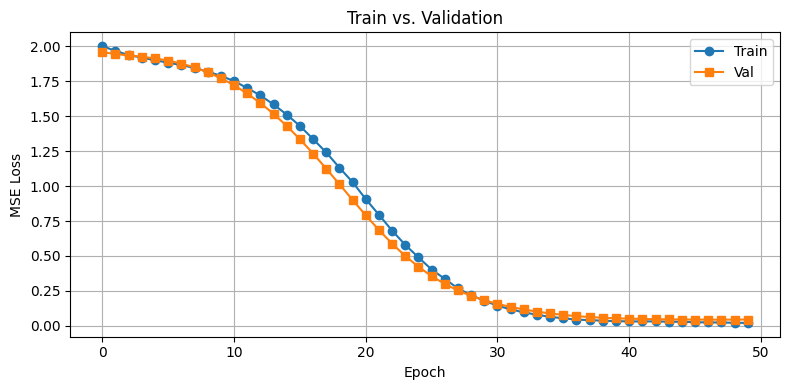

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerRegressor(
    num_gates=len(train_ds.gate2id),
    d_model=64,
    nhead=8,
    num_layers=2,
    dropout=0.1,
    max_len=train_ds.max_len
).to(device)

print("Total params:", sum(p.numel() for p in model.parameters()))

criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer,
                              mode='min',
                              factor=0.8,
                              patience=5,
                              verbose=True)

best_val_loss       = float('inf')
best_model_wts      = copy.deepcopy(model.state_dict())
patience_counter    = 0
early_stop_patience = 2

train_losses, val_losses = [], []

for epoch in range(1, 51):
    model.train()
    run_train = 0.0
    for batch in train_loader:
        g_ids   = batch["gate_ids"].to(device)
        p_feats = batch["params"].to(device)
        next_id = batch["next_gate_id"].to(device)
        target  = batch["target"].to(device)

        optimizer.zero_grad()
        pred = model(g_ids, p_feats, next_id)
        loss = criterion(pred, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        run_train += loss.item() * g_ids.size(0)

    avg_train = run_train / len(train_ds)
    train_losses.append(avg_train)

    model.eval()
    run_val = 0.0
    with torch.no_grad():
        for batch in val_loader:
            g_ids   = batch["gate_ids"].to(device)
            p_feats = batch["params"].to(device)
            next_id = batch["next_gate_id"].to(device)
            target  = batch["target"].to(device)

            pred = model(g_ids, p_feats, next_id)
            run_val += criterion(pred, target).item() * g_ids.size(0)

    avg_val = run_val / len(val_ds)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        best_model_wts   = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:2d} — train MSE: {avg_train:.4f} — val MSE: {avg_val:.4f}")
    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

# restore best weights
model.load_state_dict(best_model_wts)

# plot
plt.figure(figsize=(8,4))
plt.plot(train_losses, marker='o', label='Train')
plt.plot(val_losses,   marker='s', label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs. Validation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import inspect
print(inspect.signature(model.forward))

(gate_ids, param_feats, next_gate_id)


In [ ]:
torch.save(model.state_dict(), "transformer_regressor.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state = torch.load("transformer_regressor.pth", map_location=device)
model.load_state_dict(state)
model.eval()

# 2️⃣ turn it into TorchScript
scripted = torch.jit.script(model)
torch.jit.save(scripted, "transformer_regressor.pt")
print("Saved TorchScript model → transformer_regressor.pt")

Saved TorchScript model → transformer_regressor.pt
